In [63]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf


import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
paleta_cores = {"azul": "#003B5C", "laranja": "#F15A22", "cinza": "#D9D9D9", "verde": "#00A99D"}
sns.set_theme(style="whitegrid", context="notebook", palette=list(paleta_cores.values()), font_scale=1.2)
plt.figure(figsize=(10,4))

sns.color_palette(list(paleta_cores.values()))

[(0.0, 0.23137254901960785, 0.3607843137254902),
 (0.9450980392156862, 0.35294117647058826, 0.13333333333333333),
 (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
 (0.0, 0.6627450980392157, 0.615686274509804)]

<Figure size 1000x400 with 0 Axes>

In [65]:
df = pd.read_parquet("../data/silver/bnds_silver.parquet")

In [66]:
df.head(2)

,razao_social_cliente,cnpj_cliente,descricao_projeto,sigla_uf,nome_municipio,id_municipio,id_contrato,data_contratacao,valor_contratado,valor_desembolsado,...,ano_contratacao,mes_contratacao,prazo_total_meses,grupo_taxa_juros,grupo_taxa_juros_ordinal,flag_apoio_direto,flag_reembolsavel,flag_cliente_publico,qtd_palavras_descricao,porte_cliente_ordinal
0,COPACOL-COOPERATIVA AGROINDUSTRIAL CONSOLATA,76093731000190.0,INVESTIMENTOS EM AMPLIACAO DA CAPACIDADE DE RE...,PR,SEM MUNICIPIO,NAO INFORMADO,9203361,2009-06-30,"35,900,000.0","35,900,000.0",...,2009,6,108,MEDIA,2,0,1,0,44,4
1,LAR COOPERATIVA AGROINDUSTRIAL,77752293000198.0,DIRETA - AMPLICACAO DE LINHA DE ABATE DE FRANG...,PR,MATELANDIA,4115606.0,9203571,2009-06-29,"66,998,000.0","66,998,000.0",...,2009,6,108,MEDIA,2,1,1,0,24,4


In [80]:
y = "valor_contratado"

# Identificadores: não serão usados como variáveis explicativas
remover_id = [
    "id_contrato",
    "id_municipio",
    "cnpj_cliente",
    "cnpj_instituicao_financeira_credenciada"
]

# Remove os identificadores sem alterar o DataFrame original
df = df.drop(columns=colunas_id, errors="ignore")

df.head(2)


,descricao_projeto,sigla_uf,nome_municipio,data_contratacao,valor_contratado,valor_desembolsado,tipo_fonte_recursos,custo_financeiro,taxa_juros,prazo_carencia,...,ano_contratacao,mes_contratacao,prazo_total_meses,grupo_taxa_juros,grupo_taxa_juros_ordinal,flag_apoio_direto,flag_reembolsavel,flag_cliente_publico,qtd_palavras_descricao,porte_cliente_ordinal
0,INVESTIMENTOS EM AMPLIACAO DA CAPACIDADE DE RE...,PR,SEM MUNICIPIO,2009-06-30,"35,900,000.0","35,900,000.0",RECURSOS LIVRES - TESOURO,TAXA FIXA,6.8,18,...,2009,6,108,MEDIA,2,0,1,0,44,4
1,DIRETA - AMPLICACAO DE LINHA DE ABATE DE FRANG...,PR,MATELANDIA,2009-06-29,"66,998,000.0","66,998,000.0",RECURSOS LIVRES - TESOURO,TAXA FIXA,6.8,24,...,2009,6,108,MEDIA,2,1,1,0,24,4


In [68]:
# Seleção das variáveis do schema
colunas_num = [
    "valor_operacao", "tem_exepcionalidade","prazo_total_meses", "indicador_inovacao", 
    "porte_cliente_ordinal", "grupo_taxa_juros_ordinal", 
    "flag_apoio_direto", "flag_reembolsavel", "flag_cliente_publico","porte_cliente_ordinal", "grupo_taxa_juros_ordinal"
]

In [69]:
#formatando float com uma casas decimal
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')

In [70]:
df.describe(include="int64").T

,count,mean,std,min,25%,50%,75%,max
prazo_carencia,"23,483.0",21.0,16.3,0.0,12.0,18.0,26.0,259.0
prazo_amortizacao,"23,483.0",93.0,64.8,0.0,54.0,72.0,143.5,399.0
indicador_inovacao,"23,483.0",0.1,0.3,0.0,0.0,0.0,0.0,1.0
tem_excepcionalidade,"23,483.0",0.0,0.1,0.0,0.0,0.0,0.0,1.0
prazo_total_meses,"23,483.0",114.0,70.2,0.0,72.0,96.0,162.0,408.0
grupo_taxa_juros_ordinal,"23,483.0",1.1,0.3,1.0,1.0,1.0,1.0,3.0
flag_apoio_direto,"23,483.0",0.8,0.4,0.0,1.0,1.0,1.0,1.0
flag_reembolsavel,"23,483.0",0.9,0.3,0.0,1.0,1.0,1.0,1.0
flag_cliente_publico,"23,483.0",0.1,0.3,0.0,0.0,0.0,0.0,1.0
qtd_palavras_descricao,"23,483.0",29.4,13.9,2.0,19.0,28.0,38.0,148.0


In [71]:
df.describe(include="str").T

,count,unique,top,freq
descricao_projeto,23483,6498,CONTRATACAO DE LIMITE DE CREDITO PARA FINANCIA...,440
sigla_uf,23483,28,SP,5462
nome_municipio,23483,1126,SEM MUNICIPIO,7538
tipo_fonte_recursos,23483,103,RECURSOS LIVRES - FAT CONSTITUCIONAL,5324
custo_financeiro,23483,30,TJLP,10092
modalidade_apoio,23483,2,REEMBOLSAVEL,21899
forma_apoio,23483,2,DIRETA,19412
produto,23483,17,BNDES FINEM,15865
tipo_instrumento_financeiro,23483,185,OUTROS,2468
area_operacional_bndes,23483,13,AREA DE DESENVOLVIMENTO PRODUTIVO E INOVACAO,11795


In [ ]:
#remoção de colunas e seleção de variaveis
remover_id = [
    "razao_social_cliente",
    "nome_instituicao_financeira_credenciada",
    "subsetor_agrupado_cnae_bndes",
    "tipo_instrumento_financeiro"
]

# Remove os identificadores sem alterar o DataFrame original
df = df.drop(columns=colunas_id, errors="ignore")

In [72]:
df.describe(include="float64").T

,count,mean,std,min,25%,50%,75%,max
valor_contratado,"23,483.0","52,343,588.3","217,705,538.1",0.6,"2,186,769.0","9,462,000.0","32,556,383.2","9,889,997,970.0"
valor_desembolsado,"23,483.0","40,541,943.1","184,090,009.7",0.0,"1,224,165.9","6,645,724.2","25,240,750.0","9,889,997,970.0"
taxa_juros,"23,483.0",2.8,1.8,0.0,1.8,2.5,3.5,16.5


1. Variáveis Qualitativas/Texto
   - Grandes clientes e setor privado são **80%** dos contratos, clientes de Grande Porte representam (18.915 / 23.483) e **90%** a entidades Privadas (21.495 / 23.483). A amostra tem forte viés no perfil institucional.
     
   - O estado de SP lidera isoladamente com **23%** das operações (5.462 / 23.483). 
     
   - O Setor de Infraestrutura (9.579) e Comércio/Serviços (14.372) dominam a destinação. Operação Direta Predominante: **82%** das operações são de Apoio Direto (19.412 / 23.483), utilizando como instrumento principal o BNDES FINEM.
   -  situacao_contrato tem **liquididado** como categoria mais frequente (aproximadamente **59,7%**)


2. Variáveis Numéricas Contínuas

   - Apresenta uma assimetria positiva em valor_contratado e valor_desembolsado
     - Média: 52 milhões & Mediana: 9,46 milhões
     - o desvio padrão representa 4x vezes a média 

   - A Taxa de Juros apresenta média de **2,8% a.a**. e mediana de **2,5%**, com **75%** dos dados abaixo de **3,5%** com valor máximo de **16,5%** (possivelmente um outlier)


3. Variáveis Inteiras, Prazos e Flags
   - indicador_inovacao: Apenas ~10% da carteira envolve inovação (média 0,1)
   - tem_excepcionalidade: Praticamente nulo na base ($\text{média} \approx 0,0$).
   - prazo_carencia: apresenta uma Mediana de 18 meses (IQR = Q₃ - Q₁ -> 12 a 26 meses).
   - prazo_amortizacao: Mediana de 72 meses (6 anos), chegando até 399 meses (~33 anos).
   - prazo_total_meses: Mediana de 96 meses (8 anos). com valores mínimos de 0 meses em amortização que podem indicar estruturas atípicas ou contratações de giro imediato.


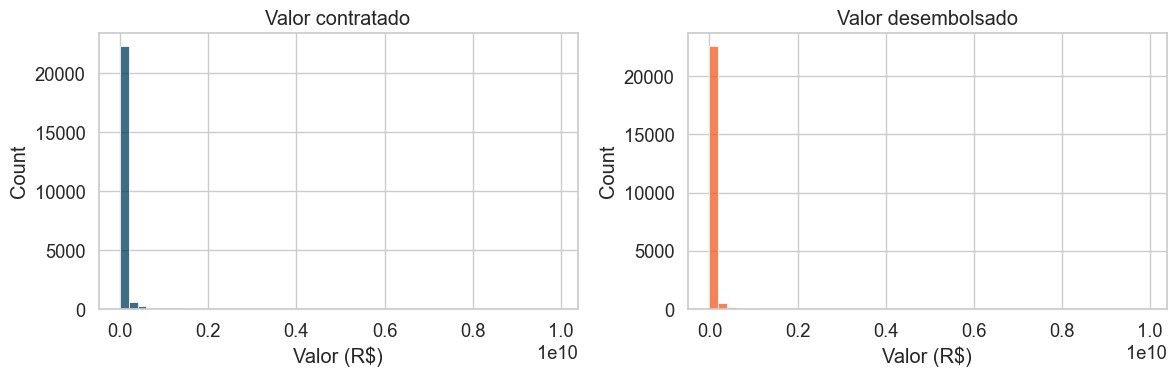

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["valor_contratado"], bins=50, stat="count", ax=axes[0], color=paleta_cores["azul"])
axes[0].set_title("Valor contratado")
axes[0].set_xlabel("Valor (R$)")

sns.histplot(df["valor_desembolsado"], bins=50, stat="count", ax=axes[1], color=paleta_cores["laranja"])
axes[1].set_title("Valor desembolsado")
axes[1].set_xlabel("Valor (R$)")

plt.tight_layout()
plt.show()

valor_contratado: skew=17.381, kurt=506.368
valor_desembolsado: skew=22.605, kurt=868.449
taxa_juros: skew=1.280, kurt=3.419


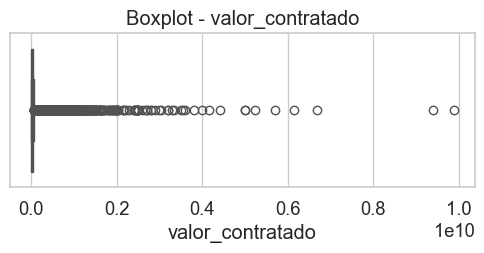

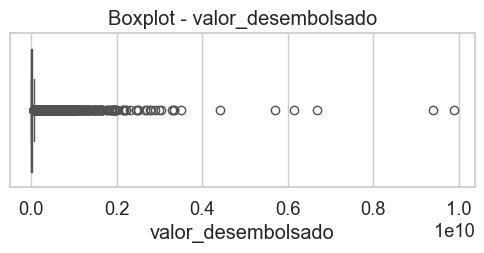

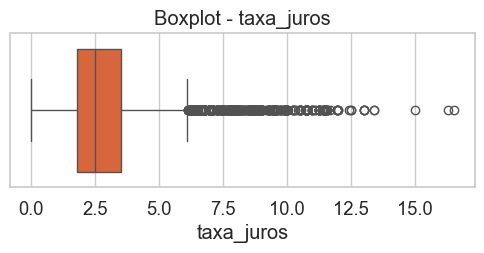

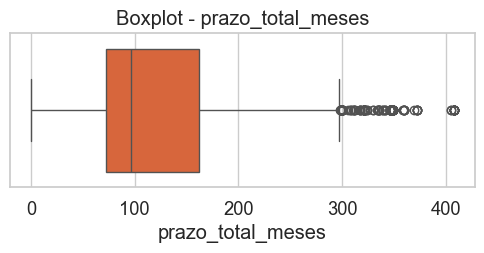

In [74]:
for c in ["valor_contratado", "valor_desembolsado", "taxa_juros"]:
    if c in df.columns:
        print(f"{c}: skew={df[c].skew():.3f}, kurt={df[c].kurt():.3f}")

# 5) Boxplot para outliers
cols_box = ["valor_contratado", "valor_desembolsado", "taxa_juros", "prazo_total_meses"]
for c in cols_box:
    if c in df.columns:
        plt.figure(figsize=(6, 2))
        sns.boxplot(x=df[c], color=paleta_cores["laranja"])
        plt.title(f"Boxplot - {c}")
        plt.show()

In [75]:

df.groupby("setor_bndes")["valor_contratado"].agg(["mean","sum","std"]).sort_values(by = "sum", ascending=False)

,mean,sum,std
setor_bndes,,,
INFRAESTRUTURA,"77,095,610.0","738,498,848,515.7","246,343,448.3"
INDUSTRIA,"35,436,483.5","291,819,441,837.0","184,869,125.5"
COMERCIO/SERVICOS,"36,765,430.2","176,216,706,799.0","218,957,483.0"
AGROPECUARIA,"25,855,578.2","22,649,486,540.3","109,823,878.8"


In [86]:
df["valor_contratado_log"] = np.log1p(df["valor_contratado"])
df["valor_desembolsado_log"] = np.log1p(df["valor_desembolsado"])

valor_contratado_log: skew=-0.244, kurt=0.355


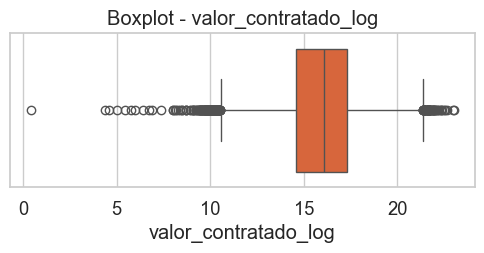

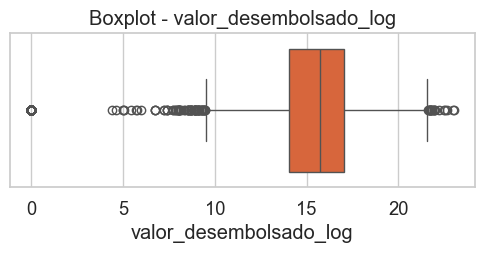

In [88]:
for c in ["valor_contratado_log", "valor_desembolsado_Log"]:
    if c in df.columns:
        print(f"{c}: skew={df[c].skew():.3f}, kurt={df[c].kurt():.3f}")

# 5) Boxplot para outliers
cols_box = ["valor_contratado_log", "valor_desembolsado_log"]
for c in cols_box:
    if c in df.columns:
        plt.figure(figsize=(6, 2))
        sns.boxplot(x=df[c], color=paleta_cores["laranja"])
        plt.title(f"Boxplot - {c}")
        plt.show()

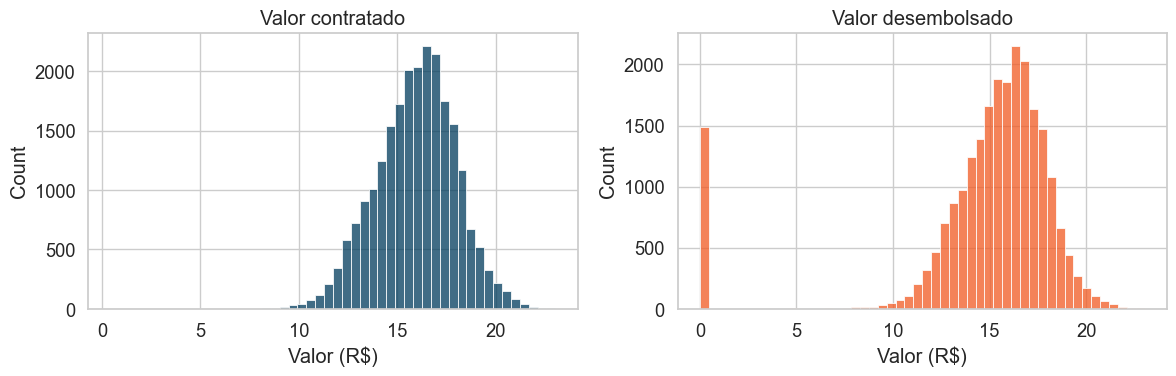

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["valor_contratado_log"], bins=50, stat="count", ax=axes[0], color=paleta_cores["azul"])
axes[0].set_title("Valor contratado")
axes[0].set_xlabel("Valor (R$)")

sns.histplot(df["valor_desembolsado_log"], bins=50, stat="count", ax=axes[1], color=paleta_cores["laranja"])
axes[1].set_title("Valor desembolsado")
axes[1].set_xlabel("Valor (R$)")

plt.tight_layout()
plt.show()

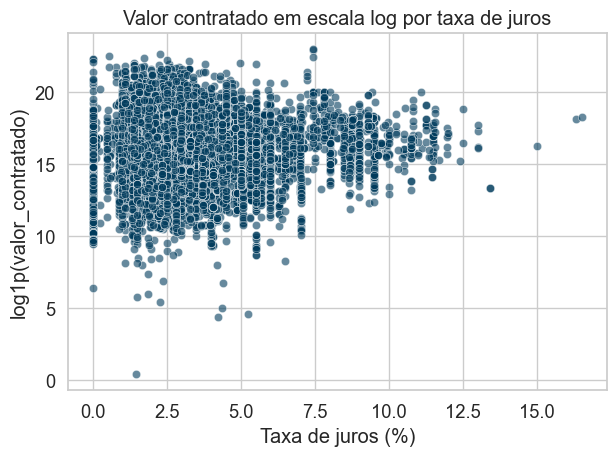

In [95]:
sns.scatterplot(
    data=df,
    x="taxa_juros",
    y="valor_contratado_log",
    alpha=0.6,
    color=paleta_cores["azul"]
)
plt.title("Valor contratado em escala log por taxa de juros")
plt.xlabel("Taxa de juros (%)")
plt.ylabel("log1p(valor_contratado)")
plt.tight_layout()
plt.show()